# Observation de la biodiversité urbaine : moineaux domestiques dans le Grand Paris Seine Ouest

## Contexte
Les données utilisées sont hébergées sur le site data.gouv et soumises par Grand Paris Seine Ouest (composé des villes Boulogne-Billancourt, Chaville, Issy-les-Moulineaux, Marnes-la-Coquette, Meudon, Sèvres, Vanves et Ville-d’Avray).

https://www.data.gouv.fr/datasets/observatoire-de-la-biodiversite-moineaux-domestiques

Grand Paris Seine Ouest offre un espace d'informations sur son site : https://www.seineouest.fr/moineau.\
On y apprend que **la collecte s'est effectuée de mars à mai 2025, avec un total de 92 observations et 296 moineaux répertoriés**.
Il y est notamment indiqué que les moineaux vivent souvent proches des habitations mais se rencontrent aussi en milieu rural.

## Termes employés
**Moineau domestique :** Le moineau domestique est une espèce faisant partie de la famille des Passeridae (passereaux), petit oiseau assez trapu, mesurant environ 16 cm de long pour un poids allant de 24 à 39,5 g.

Très commun dans la plupart des parties du globe, il originaire du bassin méditerranéen et d'une grande partie de l'Asie, il a été introduit accidentellement ou volontairement dans beaucoup d'autres régions du monde. C'est l'oiseau à l'aire de répartition la plus vaste.

Bien que l'on trouve cet oiseau dans des habitats et sous des climats très variés, il évite généralement les vastes forêts, les prairies et les déserts éloignés de l'habitat humain. 
Il est considéré comme espèce suscitant une "préoccupation mineure" selon l'Union internationale pour la conservation de la nature.\
_source : https://fr.wikipedia.org/wiki/Moineau_domestique_

**Biodiversité :** Ensemble des milieux naturels et des formes de vie (plantes, animaux, champignons, bactéries, ...) ainsi que toutes les relations et interactions (coopération, prédation, symbiose, ...) qui existent entre les organismes vivants eux-mêmes et entre ces organismes et leurs milieux de vie.\
_source : https://biodiversite.gouv.fr/la-biodiversite-cest-quoi_




# Bien que cette espèce fasse partie de celles des plus abondantes, sa population française se trouve t-elle en déclin ?

Le but est de comprendre les variations de population observées sur une année et d'explorer la possibilité de faire une première prévision simple, sur un territoire.

## Objectifs
Avant d'émettre les hypothèses, il est nécessaire d'identifier la fréquence des observations (jour, semaine, mois), les variables disponibles, les données manquantes éventuelles.

## Hypothèses
1. Le nombre de moineaux varie selon les saisons.

Par exemple : période de reproduction au printemps et plus forte mortalité ou dispersion en hiver.

2. L'influence de l'environnement urbain.

Les moineaux sont plus présents dans certains types d'espaces (comparaison entre parcs et zones urbanisées).

## Points de vigilance
Déterminer une tendance sur quelques mois ou une seule année reste fragile pour déterminer s'il y a une réelle augmentation ou diminuation. La conclusion sera donc à prendre avec recul.

De même, les données restent locales et dépendent de la régularité des observations.
Le nombre observé dépend fortement du moment de l'observation. En effet, les activités des oiseaux varient selon les moments de la journée, ce qui peut entraîner un biais d'observation.

Il est à noter que les moineaux domestiques s'activent pendant la journée. Le chant commence en moyenne 18 minutes avant le lever du soleil, les différences de luminosité dues aux nuages n'ont pratiquement aucune influence.
_source : https://fr.wikipedia.org/wiki/Moineau_domestique#cite_note-:4-36_


**Afin de structurer ce projet, il conviendrait d'utiliser une étude longitudinale, une comparaison avec d'autres territoires et l'ajout de données climatiques.**


## Lecture et traitement

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Rendre l'affichage plus lisible
plt.style.use('default')

#chargement des données
df = pd.read_csv("moineaux-domestiques.csv", sep=";")
df.head() #affichage des 5 premières lignes

,Dans quelle commune l'avez-vous observée ?,Combien d'individus avez-vous vus ?,Quand avez-vous vu ce moineau domestique ?,geo_shape,geo_point_2d,espece,periode
0,VANVES,1,2025-03-19,"{""coordinates"": [2.2968284089999997, 48.825176...","48.825176639000006, 2.2968284089999997",moineau domestique,2e trimestre 2025
1,BOULOGNE-BILLANCOURT,3,2025-03-20,"{""coordinates"": [2.2904885140000033, 48.903755...","48.90375504899998, 2.2904885140000033",moineau domestique,2e trimestre 2025
2,MEUDON,1,2025-03-21,"{""coordinates"": [2.220977275999985, 48.7956126...","48.795612635, 2.220977275999985",moineau domestique,2e trimestre 2025
3,BOULOGNE-BILLANCOURT,1,2025-03-22,"{""coordinates"": [2.2283381990000066, 48.835068...","48.835068019000005, 2.2283381990000066",moineau domestique,2e trimestre 2025
4,CHAVILLE,1,2025-03-25,"{""coordinates"": [2.1785695629999964, 48.809561...","48.80956121000003, 2.1785695629999964",moineau domestique,2e trimestre 2025


In [36]:
#Exploration des données
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Dans quelle commune l'avez-vous observée ?  92 non-null     object
 1   Combien d'individus avez-vous vus ?         92 non-null     int64 
 2   Quand avez-vous vu ce moineau domestique ?  92 non-null     object
 3   geo_shape                                   92 non-null     object
 4   geo_point_2d                                92 non-null     object
 5   espece                                      92 non-null     object
 6   periode                                     92 non-null     object
dtypes: int64(1), object(6)
memory usage: 5.2+ KB


Index(['Dans quelle commune l'avez-vous observée ?',
       'Combien d'individus avez-vous vus ?',
       'Quand avez-vous vu ce moineau domestique ?', 'geo_shape',
       'geo_point_2d', 'espece', 'periode'],
      dtype='object')

### Observation :
Lors de l'importation des données, un problème de format a été identifié : l'ensemble des variables était regroupé dans une seule colonne.

Ce problème a été résolu en spécifiant le séparateur ";" utilisé dans le fichier csv, permettant ainsi de structurer correctement les données.

Par ailleurs, certains noms de colonnes sont trop longs, il convient de les retravailler.

In [37]:
df = df.rename(columns={
    "Dans quelle commune l'avez-vous observée ?": "commune",
    "Combien d'individus avez-vous vus ?": "nombre",
    "Quand avez-vous vu ce moineau domestique ?": "date"
})

df.columns

Index(['commune', 'nombre', 'date', 'geo_shape', 'geo_point_2d', 'espece',
       'periode'],
      dtype='object')

In [38]:
#conversion des dates
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   commune       92 non-null     object        
 1   nombre        92 non-null     int64         
 2   date          92 non-null     datetime64[ns]
 3   geo_shape     92 non-null     object        
 4   geo_point_2d  92 non-null     object        
 5   espece        92 non-null     object        
 6   periode       92 non-null     object        
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 5.2+ KB


,commune,nombre,date,geo_shape,geo_point_2d,espece,periode
0,VANVES,1,2025-03-19,"{""coordinates"": [2.2968284089999997, 48.825176...","48.825176639000006, 2.2968284089999997",moineau domestique,2e trimestre 2025
1,BOULOGNE-BILLANCOURT,3,2025-03-20,"{""coordinates"": [2.2904885140000033, 48.903755...","48.90375504899998, 2.2904885140000033",moineau domestique,2e trimestre 2025
2,MEUDON,1,2025-03-21,"{""coordinates"": [2.220977275999985, 48.7956126...","48.795612635, 2.220977275999985",moineau domestique,2e trimestre 2025
3,BOULOGNE-BILLANCOURT,1,2025-03-22,"{""coordinates"": [2.2283381990000066, 48.835068...","48.835068019000005, 2.2283381990000066",moineau domestique,2e trimestre 2025
4,CHAVILLE,1,2025-03-25,"{""coordinates"": [2.1785695629999964, 48.809561...","48.80956121000003, 2.1785695629999964",moineau domestique,2e trimestre 2025


In [39]:
df['date'].isna().sum()

0

La colonne correspondant à la date d'observation a été convertie au format datetime. Cette opération permet de manipuler facilement les données dans le temps, telle l'extraction du mois ou du jour.

In [40]:
#Création des variables mois et jour
df['mois'] = df['date'].dt.month
df['jour'] = df['date'].dt.day

df[['date', 'mois', 'jour']].head()

,date,mois,jour
0,2025-03-19,3,19
1,2025-03-20,3,20
2,2025-03-21,3,21
3,2025-03-22,3,22
4,2025-03-25,3,25


### Analyse de la saisonnalité
Calcul du nombre moyen de moineaux par mois

In [41]:
mois_counts = df.groupby('mois')['nombre'].mean()
mois_counts

mois
2    3.500000
3    2.631579
4    3.146341
5    3.758621
6    1.000000
Name: nombre, dtype: float64

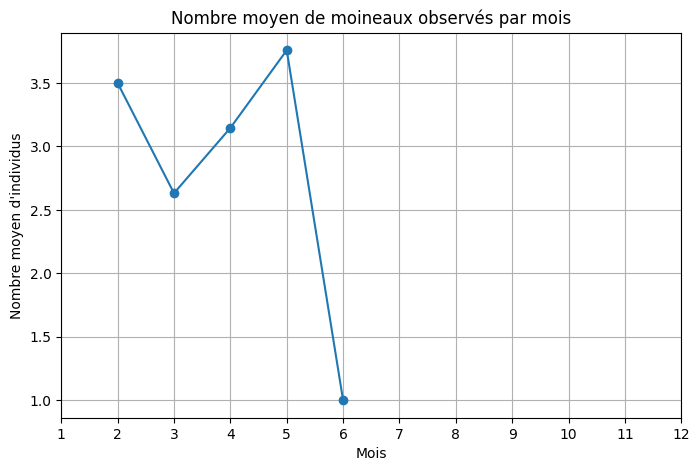

In [42]:
plt.figure(figsize=(8,5))
plt.plot(mois_counts.index, mois_counts.values, marker='o', linestyle='-')
plt.title("Nombre moyen de moineaux observés par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre moyen d'individus")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

Cette courbe montre que le nombre moyen de moineaux varie au cours des mois.
Une légère augmentation est observable en mai, ce qui correspond à la période de reproduction (période pouvant s'étendre jusqu'en juillet).
Selon la Ligue pour la Protection des Oiseaux, la femelle pond entre 2 à 5 oeufs entre fin avril et début mai.
Le moineau domestique effectue jusqu’à 4 pontes par an, lorsque le climat est favorable.

Source : https://www.lpo.fr/decouvrir-la-nature/fiches-especes/fiches-especes/oiseaux/moineau-domestique

L'absence de données sur les mois suivants est explicable par l'arrêt de récolte dès mai.

### Analyse par commune
Nombre moyen d'individus par commune.

In [43]:
commune_counts = df.groupby('commune')['nombre'].mean().sort_values(ascending=False)
commune_counts

commune
ISSY-LES-MOULINEAUX     4.360000
VANVES                  3.153846
CHAVILLE                3.055556
BOULOGNE-BILLANCOURT    2.789474
MEUDON                  2.666667
VILLE D'AVRAY           1.800000
SEVRES                  1.666667
Name: nombre, dtype: float64

In [44]:
import geopandas as gpd
import json
from shapely.geometry import shape

df['geometry'] = df['geo_shape'].apply(lambda x: shape(json.loads(x)))
gdf = gpd.GeoDataFrame(df, geometry='geometry')

In [45]:
commune_counts = df.groupby('commune')['nombre'].mean().reset_index()
commune_counts.columns = ['commune', 'nombre_moyen']

gdf = gdf.merge(commune_counts, on='commune')

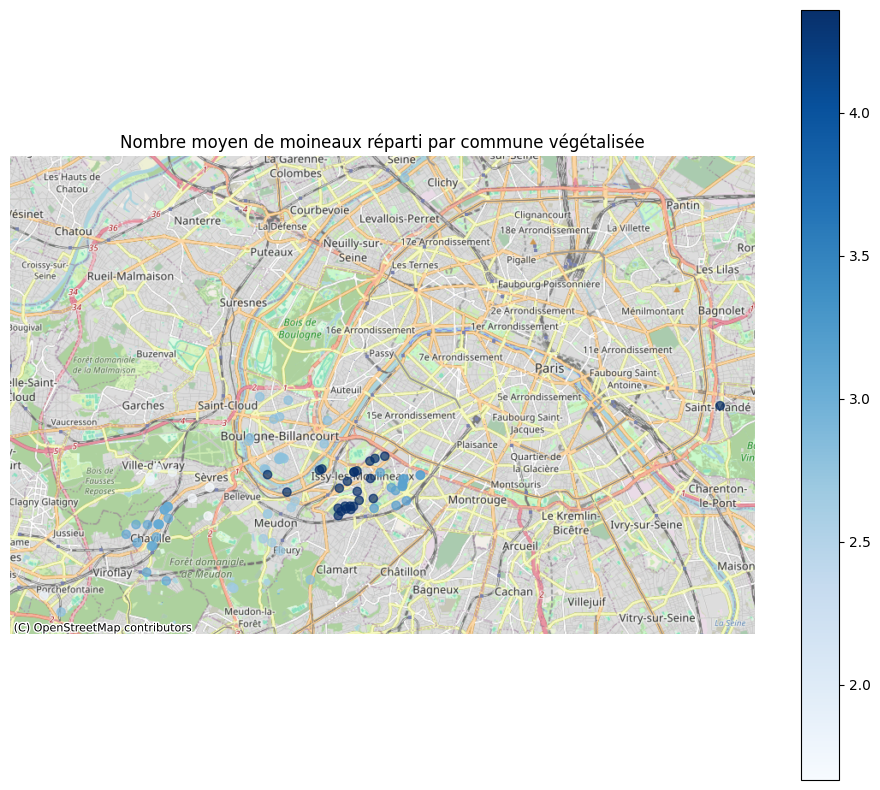

In [46]:
#Création de la carte
import contextily as ctx

#coordonnées
gdf = gdf.set_crs(epsg=4326)
gdf = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12,10))

gdf.plot(
    column='nombre_moyen',
    cmap='Blues',
    alpha=0.7,
    legend=True,        
    ax=ax
)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.title("Nombre moyen de moineaux réparti par commune végétalisée")
ax.axis('off')

plt.show()

La carte montre que certaines communes présentent un nombre moyen de moineaux plus élevé (ex : Issy-les-moulineaux).
Cela pourrait être lié à la présence de zones végétalisées plus importantes ou à une différence des activités humaines.
L'observation reste indicative dans la mesure où elle ne prend pas en compte la surface des communes ni la fréquence exacte des observations.

### Heatmap de saisonnalité x communes

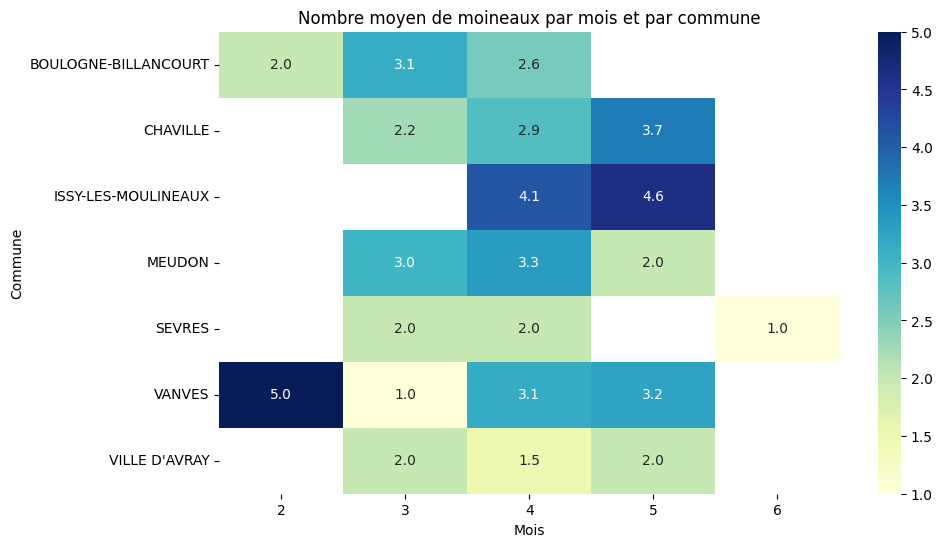

In [47]:
#Moyenne mensuelle par commune
commune_mois = df.groupby(['mois', 'commune'])['nombre'].mean().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(commune_mois.T, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Nombre moyen de moineaux par mois et par commune")
plt.xlabel("Mois")
plt.ylabel("Commune")
plt.show()

En combinant les observations par mois et par commune, nous constatons que certaines communes présentent des variations plus marquées au printemps.
Par exemple, la ville de Vanves connaît un nombre d'observations plus haut en février.

### Prévision globale (modèles)
Moyenne mobile

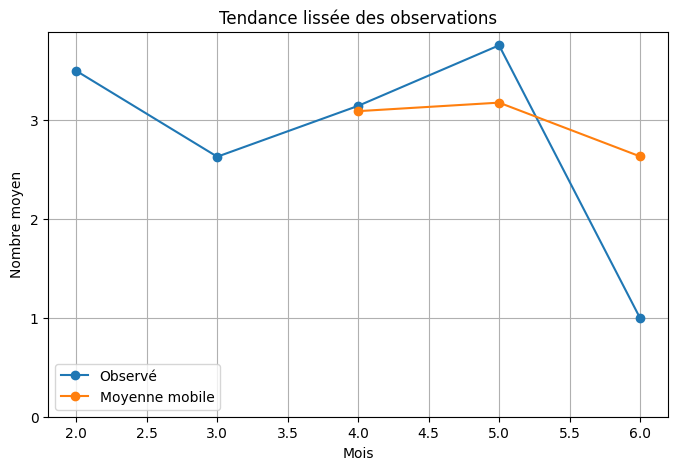

In [51]:
from matplotlib.ticker import MaxNLocator

mois_global_df = mois_counts.reset_index()
mois_global_df['moyenne_mobile'] = mois_global_df['nombre'].rolling(window=3).mean()

plt.figure(figsize=(8,5))

plt.plot(mois_global_df['mois'], mois_global_df['nombre'], marker='o', label='Observé')
plt.plot(mois_global_df['mois'], mois_global_df['moyenne_mobile'], marker='o', label='Moyenne mobile')

plt.title("Tendance lissée des observations")
plt.xlabel("Mois")
plt.ylabel("Nombre moyen")

plt.ylim(bottom=0)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

plt.legend()
plt.grid(True)

plt.show()

Afin de mieux visualiser la tendance générale, une moyenne mobile sur 3 mois a été appliquée.
Cette méthode permet de lisser les variations et de faire ressortir une tendance globale plus lisible.

### Régression linaire : prévision simple
Modélisatin de la tendance : 
y = ax + b

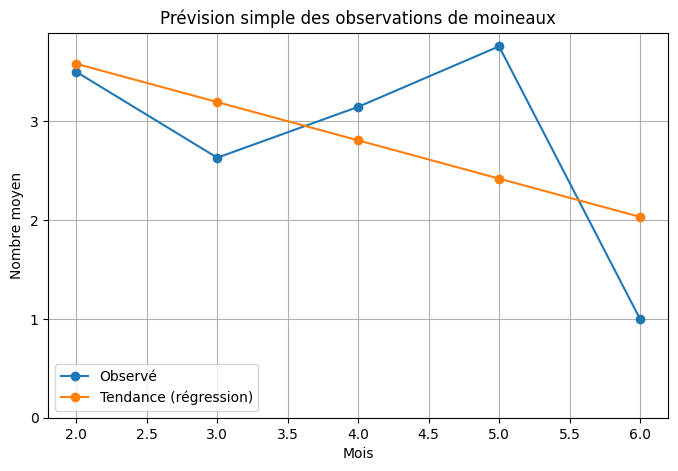

In [53]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

X = mois_global_df[['mois']]
y = mois_global_df['nombre']

model = LinearRegression()
model.fit(X, y)

mois_global_df['prediction'] = model.predict(X)

plt.figure(figsize=(8,5))

plt.plot(mois_global_df['mois'], mois_global_df['nombre'], marker='o', label='Observé')
plt.plot(mois_global_df['mois'], mois_global_df['prediction'], marker='o', label='Tendance (régression)')

plt.title("Prévision simple des observations de moineaux")
plt.xlabel("Mois")
plt.ylabel("Nombre moyen")

plt.ylim(bottom=0)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

plt.legend()
plt.grid(True)

plt.show()

Une régression linéaire a été utilisée pour modéliser la tendance des observations au cours du temps.
Le modèle met en évidence une tendance globale, attirée par les extrêmes. Toutefois, cette prévision ne peut rester fiable du fait du nombre limité de données.

### Conclusion
Les modèles valident les hypothèses : la diminution pourrait fortement s'expliquer par les variations de saisons, l'environnement, et le nombre d'observateurs.

Ce travail constitue une première exploration des dynamiques de biodiversité urbaine.
Des données complémentaires telles que les variables environnementales (climat, végétation), les comparaisons avec d'autres territoires et les études longitudinales seront efficaces pour affiner les prédictions.\
Enfin, une autre heatmap pourrait être ajoutée afin de visualiser le nombre d'habitants par commune X nombre d'observateurs.